In [1]:
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import skimage
from scipy.ndimage import generic_filter
from sklearn.neighbors import NearestNeighbors
from skimage.feature import canny, blob_log
from skimage.morphology import dilation, disk
from skimage.filters import gaussian


In [2]:
def blob_detection(gray, freq, texture, min_radius, max_radius, num_sigma, threshold, texture_thresh=0.5):
    blobs = blob_log(
        freq,
        min_sigma=min_radius / np.sqrt(2),
        max_sigma=max_radius / np.sqrt(2),
        num_sigma=num_sigma,
        threshold=threshold
    )
    blobs[:, 2] *= np.sqrt(2)

    filtered_blobs = []
    for y, x, r in blobs:
        if texture[int(y), int(x)] < texture_thresh:
            filtered_blobs.append((y, x, r))

    filtered_blobs = np.array(filtered_blobs)

    coords = np.array([[y, x] for y, x, _ in filtered_blobs])
    nbrs = NearestNeighbors(radius=10).fit(coords)
    neighbors = nbrs.radius_neighbors(coords, return_distance=False)

    final_blobs = []
    for i, neigh in enumerate(neighbors):
        if len(neigh) < 6:
            final_blobs.append(filtered_blobs[i])

    final_blobs = np.array(final_blobs)

    edges = canny(gray, sigma=3.0)
    edges = dilation(edges, disk(7))

    edge_filtered = []
    for y, x, r in final_blobs:
        if not edges[int(y), int(x)]:
            edge_filtered.append((y, x, r))
    edge_filtered = np.array(edge_filtered)
    return edge_filtered

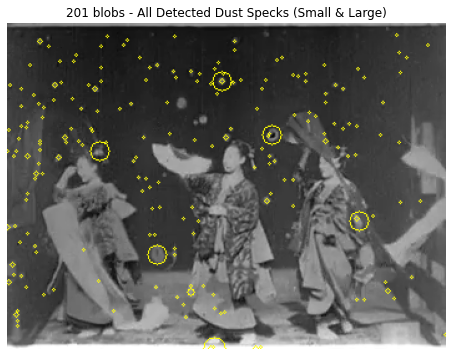

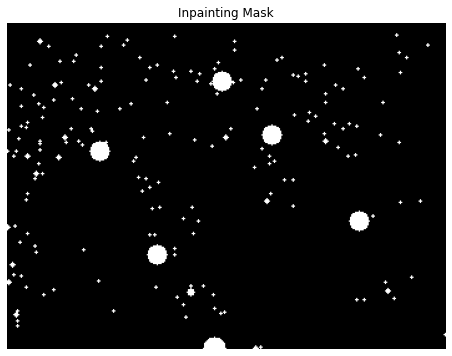

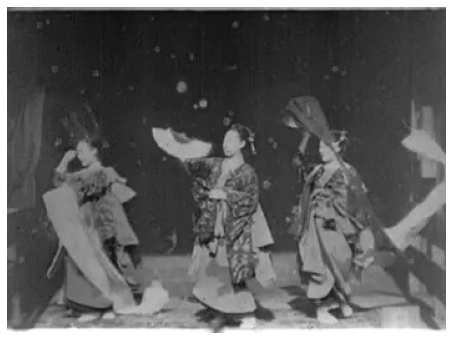

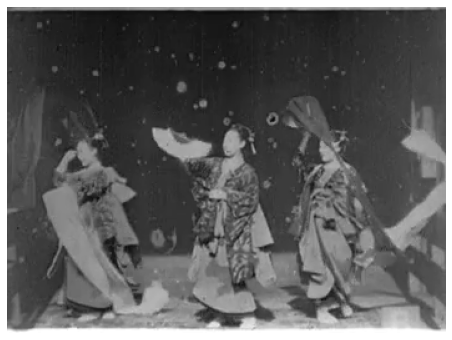

In [6]:
image = Image.open("video1/00000039.png")
image = np.array(image)
H,W,_ = image.shape
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

texture = generic_filter(gray, np.std, size=7)
texture /= texture.max()

low_freq = gaussian(gray, sigma=2)
high_freq = gray - low_freq

MAX_SMALL_RADIUS = 6
MIN_SMALL_RADIUS = 1.5
NUM_SIGMA_SMALL = 12
THRESHOLD_SMALL = 0.02
TEXTURE_THRESHOLD_SMALL = 0.5

MAX_LARGE_RADIUS = 16
MIN_LARGE_RADIUS = 8
NUM_SIGMA_LARGE = 32
THRESHOLD_LARGE = 0.01
TEXTURE_THRESHOLD_LARGE = 0.7

edge_filtered_small = blob_detection(gray, high_freq, texture, MIN_SMALL_RADIUS, MAX_SMALL_RADIUS, NUM_SIGMA_SMALL, THRESHOLD_SMALL, TEXTURE_THRESHOLD_SMALL)
edge_filtered_large = blob_detection(gray, high_freq, texture, MIN_LARGE_RADIUS, MAX_LARGE_RADIUS, NUM_SIGMA_LARGE, THRESHOLD_LARGE, TEXTURE_THRESHOLD_LARGE)
filtered_large_blobs = []
contrast_threshold = .25
#filter large false detections
for i in range(len(edge_filtered_large)):
    y,x,r = edge_filtered_large[i]
    y,x,r = int(y),int(x),int(r)
    y0 = max(0, y - r)
    y1 = min(H, y + r + 1)
    x0 = max(0, x - r)
    x1 = min(W, x + r + 1)
    patch = gray[y0:y1, x0:x1]

    if patch.std()/patch.mean() > contrast_threshold:
        filtered_large_blobs.append([y,x,r])

filtered_large_blobs = np.array(filtered_large_blobs)

all_detected_blobs = np.concatenate([edge_filtered_small, filtered_large_blobs], axis=0)

# ============================================================
# VISUALIZATION
# ============================================================
output = image.copy()
for y, x, r in all_detected_blobs:
    y, x, r = int(y), int(x), int(r)
    cv2.circle(output, (x, y), r, (0, 255, 255), 1)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f'{len(all_detected_blobs)} blobs - All Detected Dust Specks (Small & Large)')
plt.show()

# ============================================================
# MASK CREATION
# ============================================================
mask = np.zeros(gray.shape, dtype=np.uint8)

for y, x, r in all_detected_blobs:
    cv2.circle(mask, (int(x), int(y)), int(r), 255, -1)

plt.figure(figsize=(10, 6))
plt.imshow(mask, cmap="gray")
plt.title("Inpainting Mask")
plt.axis("off")
plt.show()

# ============================================================
# INPAINTING
# ============================================================
restored = cv2.inpaint(image, mask, 3, cv2.INPAINT_NS)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(restored, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()



In [ ]:
#temporal filter on false detections

# def blob_detector(img):
#     img = np.array(img)
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

#     texture = generic_filter(gray, np.std, size=7)
#     texture /= texture.max()

#     low_freq = gaussian(gray, sigma=2)
#     high_freq = gray - low_freq

#     MAX_SMALL_RADIUS = 6
#     MIN_SMALL_RADIUS = 1.5
#     NUM_SIGMA_SMALL = 12
#     THRESHOLD_SMALL = 0.02
#     TEXTURE_THRESHOLD_SMALL = 0.5

#     MAX_LARGE_RADIUS = 16
#     MIN_LARGE_RADIUS = 8
#     NUM_SIGMA_LARGE = 32
#     THRESHOLD_LARGE = 0.01
#     TEXTURE_THRESHOLD_LARGE = 0.7
#     edge_filtered_small = blob_detection(gray, high_freq, texture, MIN_SMALL_RADIUS, MAX_SMALL_RADIUS, NUM_SIGMA_SMALL, THRESHOLD_SMALL, TEXTURE_THRESHOLD_SMALL)
#     edge_filtered_large = blob_detection(gray, high_freq, texture, MIN_LARGE_RADIUS, MAX_LARGE_RADIUS, NUM_SIGMA_LARGE, THRESHOLD_LARGE, TEXTURE_THRESHOLD_LARGE)
#     filtered_large_blobs = []
#     #filter large false detections
#     for i in range(len(edge_filtered_large)):
#         y,x,r = edge_filtered_large[i]
#         y,x,r = int(y),int(x),int(r)
#         y0 = max(0, y - r)
#         y1 = min(H, y + r + 1)
#         x0 = max(0, x - r)
#         x1 = min(W, x + r + 1)
#         patch = gray[y0:y1, x0:x1]

#         if patch.std()/patch.mean() > .25:
#             filtered_large_blobs.append([y,x,r])

#     filtered_large_blobs = np.array(filtered_large_blobs)

#     all_detected_blobs = np.concatenate([edge_filtered_small, filtered_large_blobs], axis=0)
#     return all_detected_blobs

# all_blobs = []
# for i in range(39,44):
#     image = Image.open(f"video1/000000{i}.png")
#     all_blobs.append(blob_detector(image))

# T = len(all_blobs)
# support = [ [0]*len(all_blobs[t]) for t in range(T) ]
# d_max = 2
# r_max = .1
# for t in range(T):
#     for i, (x, y, r) in enumerate(all_blobs[t]):
#         for dt in [-1, 1]:   # previous and next frame
#             t2 = t + dt
#             if t2 < 0 or t2 >= T:
#                 continue

#             for (x2, y2, r2) in all_blobs[t2]:
#                 #print(np.hypot(x-x2, y-y2),abs(r-r2))
#                 if np.hypot(x-x2, y-y2) < d_max and abs(r-r2) < r_max:
#                     support[t][i] += 1
#                     break   # one match is enough

# filtered_blobs = []
# min_support = 1
# for t in range(T):
#     frame_blobs = []
#     for i, blob in enumerate(all_blobs[t]):
#         if support[t][i] >= min_support:
#             frame_blobs.append(blob)
#     filtered_blobs.append(frame_blobs)

# for i in filtered_blobs:
#     print(len(i))

# image = np.array(Image.open("video1/00000040.png"))
# output = image.copy()
# for y, x, r in filtered_blobs[1]:
#     y, x, r = int(y), int(x), int(r)
#     cv2.circle(output, (x, y), r, (0, 255, 255), 1)

# plt.figure(figsize=(10, 6))
# plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
# plt.axis("off")
# plt.title(f'{len(filtered_blobs[1])} blobs - All Detected Dust Specks (Small & Large)')
# plt.show()